# 02 · Does the BMP4 mask predict *cell density*?

Notebook 01 found that the illuminated ring is also a **low cell-density** region,
and that smoothed cell density correlates with T at +0.69 — comparable in strength to
the BMP4 relationship itself.

That makes density a confound rather than a nuisance: if the mask predicts density,
and density predicts the markers, then a marker score obtained from mask features
cannot be attributed to BMP4 signalling without further work. This notebook measures
the first link directly, by making **density the prediction target**.

The result is what licenses (or forbids) the causal reading of notebooks 03 and 04.

In [1]:
import sys, os
sys.path.append('../src')

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tools.dataset import load_well, marker_positive, IF_BACKGROUNDS, PRIMARY_WELL, MATCHED_PAIR, RESULTS
from tools.spatial import PYRAMID_SCALES
import tools.evaluation as ev
import plotting as pl

pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 110

In [2]:
from tools.spatial import add_mask_pyramid, add_density_pyramid
from models.graph import border_mask
from models.recipe import RADIUS, MAX_SIGMA, build_data
from tools.morphology import indices_to_mask
from sklearn.ensemble import HistGradientBoostingRegressor

df = load_well(PRIMARY_WELL)
centroids = df[['centroid_y', 'centroid_x']].to_numpy(np.float32)
mask_cols = add_mask_pyramid(df, 'BMP4_bin', geometry=True)
dens_cols = add_density_pyramid(df)
print(f'{len(df):,} cells')
print('mask features   :', mask_cols)
print('density features:', dens_cols)

111,511 cells
mask features   : ['BMP4_bin_gauss_15', 'BMP4_bin_gauss_30', 'BMP4_bin_gauss_60', 'BMP4_bin_gauss_120', 'BMP4_bin_gauss_240', 'BMP4_bin_gauss_480', 'BMP4_bin_gauss_960', 'BMP4_bin_gauss_1920', 'BMP4_bin_signed_dist', 'BMP4_bin_log_dist_pos', 'BMP4_bin_log_dist_neg']
density features: ['dens_15', 'dens_30', 'dens_60', 'dens_120', 'dens_240', 'dens_480', 'dens_960', 'dens_1920']


## The two fields, side by side

If the illuminated region were density-neutral there would be no confound to worry
about. It is not.

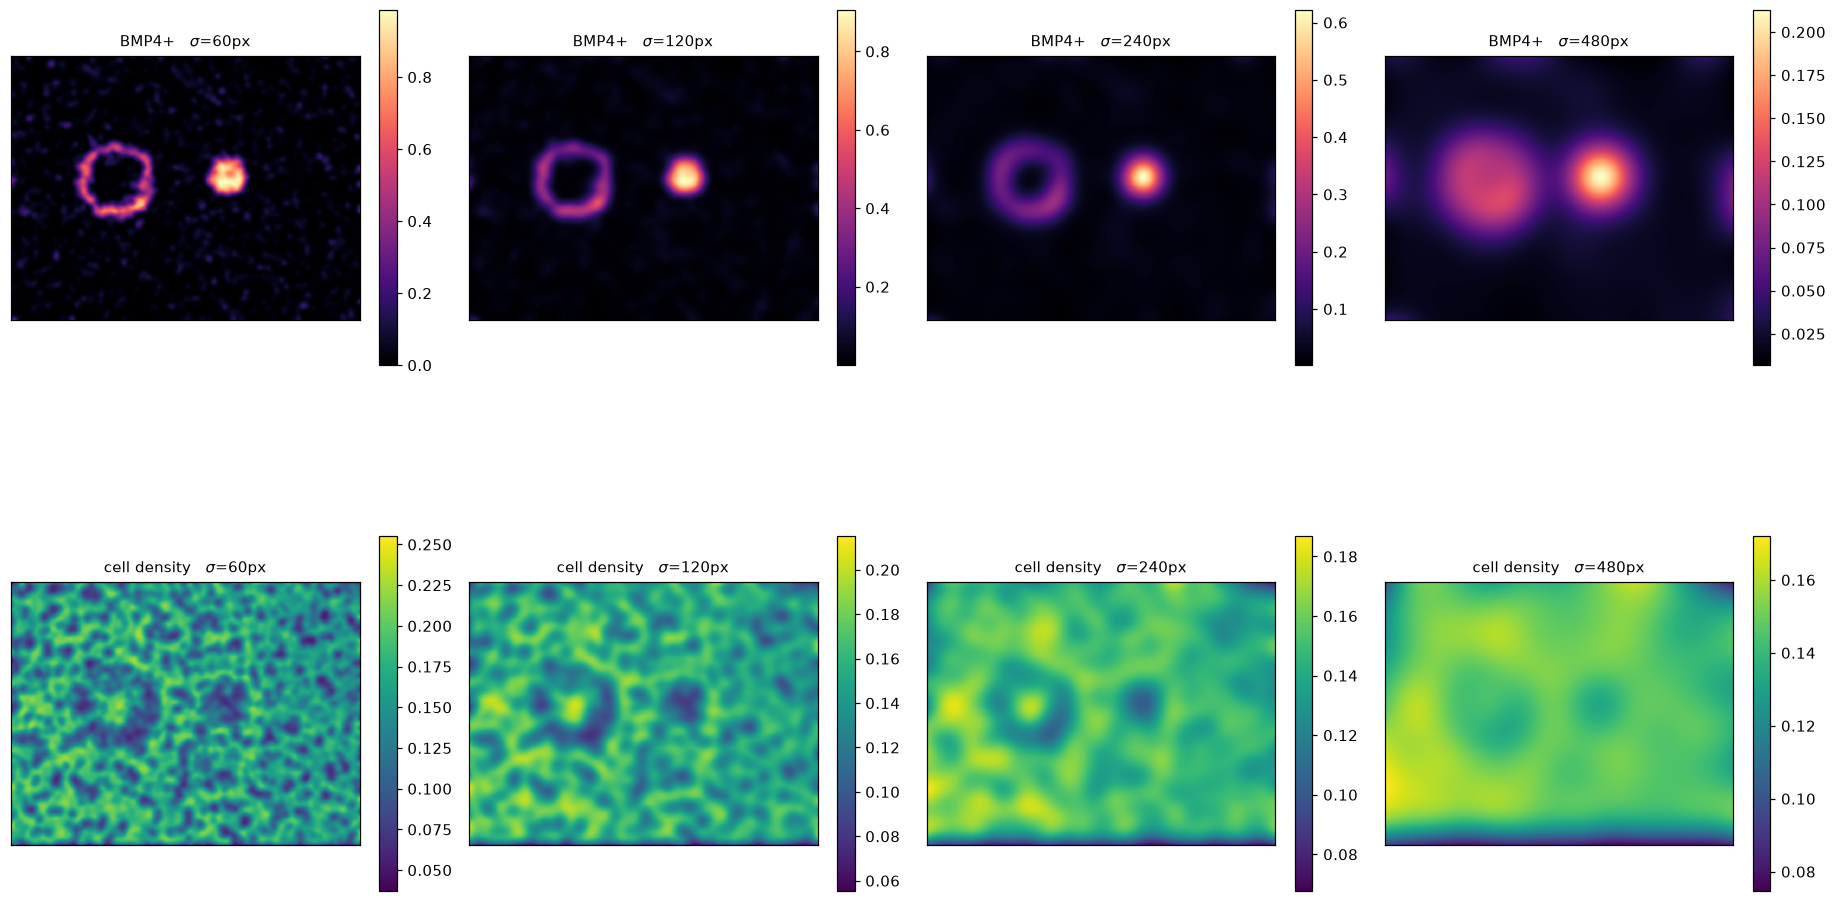

In [3]:
fig = pl.plot_field_grid(df, rows=[('BMP4+', 'BMP4_bin'), ('cell density', None)],
                         sigmas=[60, 120, 240, 480])
plt.show()

## Target: local cell density

Density at σ = 60px, log-transformed (it is a count, so its scale is multiplicative),
then rescaled to [0, 1] so R² is comparable with the marker notebooks.

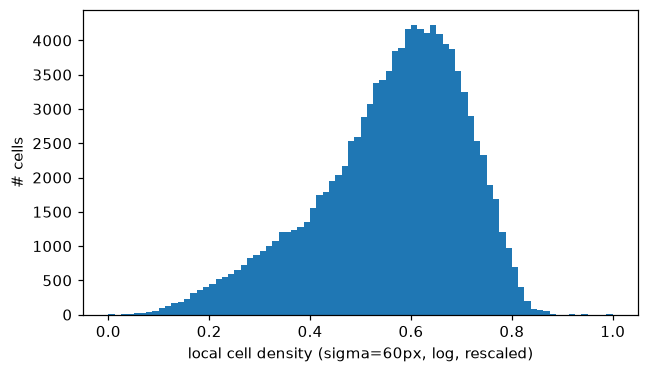

In [4]:
TARGET_SIGMA = 60
raw_density = df[f'dens_{TARGET_SIGMA}'].to_numpy(np.float32)
y_density = np.log1p(raw_density)
y_density = ((y_density - y_density.min()) / (y_density.max() - y_density.min())).astype(np.float32)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(y_density, bins=80)
ax.set_xlabel(f'local cell density (sigma={TARGET_SIGMA}px, log, rescaled)')
ax.set_ylabel('# cells')
plt.tight_layout(); plt.show()

## Splits

Both are reported throughout this project:

- **random** — held-out *cells*. Every test cell's own physical neighbours stay in
  train, so a purely local smoother scores well.
- **blocked** — held-out *regions* (800px tiles). This is what "generalises" means.

The gap between them measures how much a score depends on spatial autocorrelation.

In [5]:
shape = (int(centroids[:,0].max())+2, int(centroids[:,1].max())+2)
valid = np.where(~border_mask(centroids, shape, RADIUS))[0]

splits = {
    'random':  tuple(valid[i] for i in ev.random_split(len(valid), seed=0)),
    'blocked': tuple(valid[i] for i in ev.spatial_block_split(centroids[valid], block=800.0, seed=0)),
}
for k, (tr, va, te) in splits.items():
    print(f'{k:8s} train/val/test = {len(tr):,}/{len(va):,}/{len(te):,}')

random   train/val/test = 76,681/16,432/16,432
blocked  train/val/test = 76,751/17,508/15,286


## Fit

Gradient boosting here rather than the GNN: the question is *how much information the
mask carries about density*, and a fast, strong tabular learner answers that without
the graph quietly re-introducing density through its own weighted-sum aggregation
(which is exactly what `normalize_data=False` does — see notebook 04).

In [6]:
rows = []
# excludes 'BMP4_bin_signed_dist' -- same exclusion recipe.mask_features makes for
# the GNN (see its docstring): an unbounded raw distance whose scale tracks the
# SIZE of the illuminated pattern, not validated beyond the one matched well pair.
mask_cols_no_signed = [c for c in mask_cols if c != 'BMP4_bin_signed_dist']

FEATURE_SETS = {
    'mask, local only (sigma<=30)': ['BMP4_bin'] + [c for c in mask_cols if c.endswith(('_15','_30'))],
    'mask + context (sigma<=240)' : ['BMP4_bin'] + [c for c in mask_cols_no_signed
                                                     if not c.startswith('BMP4_bin_gauss_')
                                                     or int(c.rsplit('_',1)[1]) <= MAX_SIGMA],
    'mask + all scales'           : ['BMP4_bin'] + mask_cols_no_signed,
}

for split_name, (tr, va, te) in splits.items():
    for fname, cols in FEATURE_SETS.items():
        X = df[cols].to_numpy(np.float32)
        m = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.06, max_leaf_nodes=31,
                                          l2_regularization=5.0, early_stopping=False,
                                          random_state=0).fit(X[tr], y_density[tr])
        met = ev.evaluate(y_density[te], m.predict(X[te]))
        rows.append(dict(split=split_name, features=fname, **met))
        print(f'{split_name:8s} {fname:30s} R2={met["r2"]:+.4f}  spearman={met["spearman"]:+.3f}')

density_results = pd.DataFrame(rows)
density_results.round(4)

random   mask, local only (sigma<=30)   R2=+0.4175  spearman=+0.573
random   mask + context (sigma<=240)    R2=+0.5668  spearman=+0.701
random   mask + all scales              R2=+0.7454  spearman=+0.848
blocked  mask, local only (sigma<=30)   R2=+0.4720  spearman=+0.631
blocked  mask + context (sigma<=240)    R2=+0.5746  spearman=+0.724
blocked  mask + all scales              R2=+0.5078  spearman=+0.676


,split,features,r2,pearson,spearman
0,random,"mask, local only (sigma<=30)",0.4175,0.6463,0.5728
1,random,mask + context (sigma<=240),0.5668,0.7531,0.7015
2,random,mask + all scales,0.7454,0.8663,0.8482
3,blocked,"mask, local only (sigma<=30)",0.4720,0.6882,0.6314
4,blocked,mask + context (sigma<=240),0.5746,0.7584,0.7240
5,blocked,mask + all scales,0.5078,0.7171,0.6758


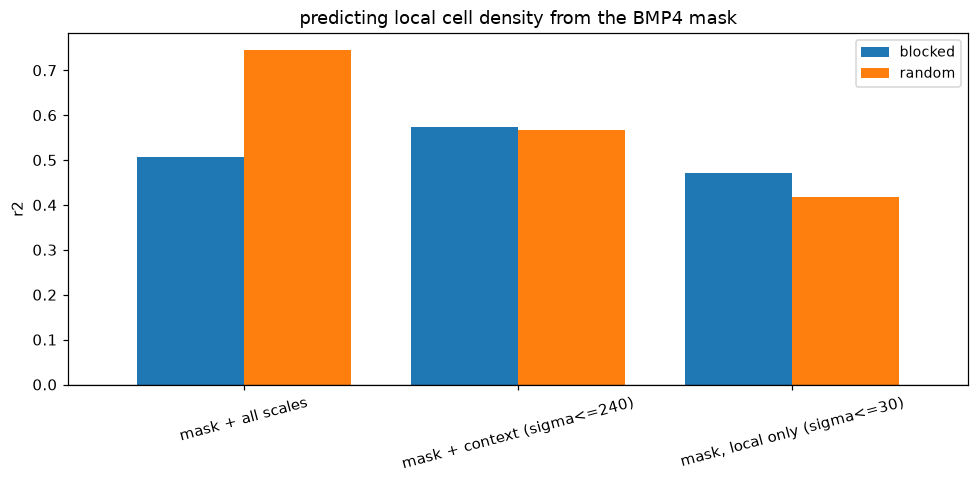

In [7]:
pl.plot_metric_comparison(density_results, metric='r2', group='features', hue='split',
                          title='predicting local cell density from the BMP4 mask')
plt.show()

## Where the prediction is right, and where it is wrong

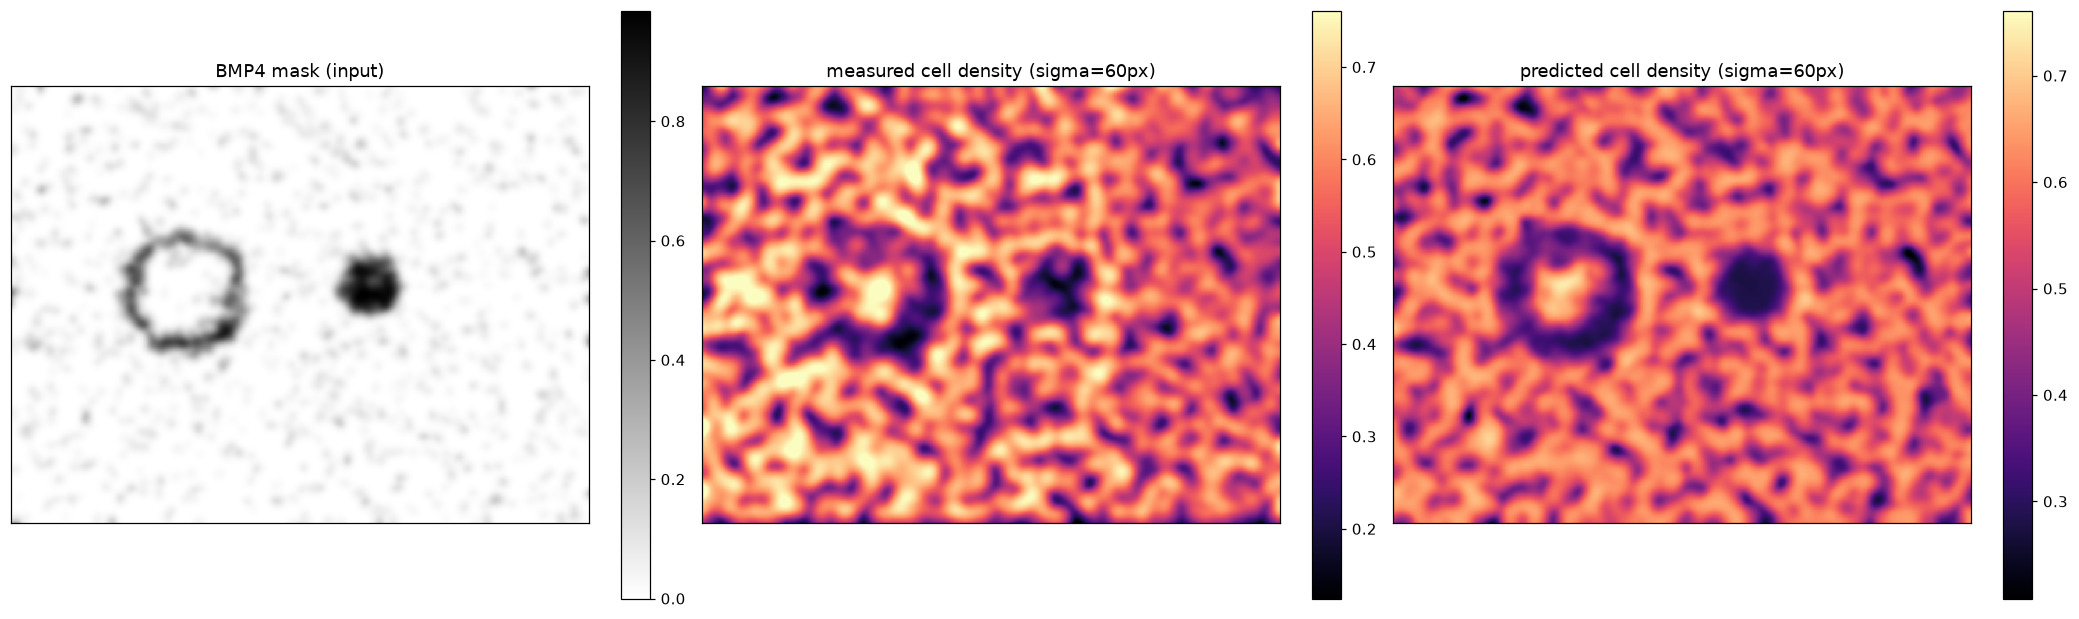

In [8]:
cols = FEATURE_SETS['mask + context (sigma<=240)']
X = df[cols].to_numpy(np.float32)
tr, va, te = splits['blocked']
best = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.06, max_leaf_nodes=31,
                                     l2_regularization=5.0, early_stopping=False,
                                     random_state=0).fit(X[tr], y_density[tr])
pred_density = best.predict(X)

pl.plot_prediction_panel(df, 'BMP4_bin', y_density, pred_density,
                         target_name=f'cell density (sigma={TARGET_SIGMA}px)',
                         mask_name='BMP4 mask (input)', smooth_sigma=60)
plt.show()

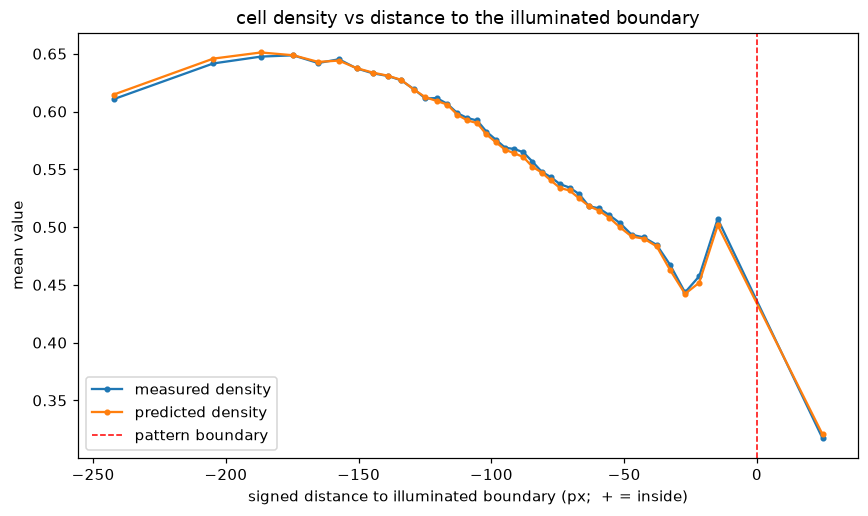

In [9]:
pl.plot_response_curve(df['BMP4_bin_signed_dist'], targets=[
    ('measured density', y_density), ('predicted density', pred_density)],
    title='cell density vs distance to the illuminated boundary')
plt.show()

## Read-out

The mask predicts density well **inside and around the illuminated pattern** and
poorly everywhere else — which is exactly what "the illumination depresses local cell
density" looks like. The response curve makes the effect explicit: density drops
inside the boundary.

**Consequence for notebooks 03 and 04.** Mask features and density features are not
independent inputs. Any marker score from the mask has a route through density, and
the honest baseline for "BMP4 predicts the marker" is therefore *not* zero — it is
whatever density alone achieves. Notebook 04 measures that baseline, and the two must
be read together.

In [10]:
density_results.to_csv(f'{RESULTS}/02_density_from_mask.csv', index=False)
print(f'saved -> {RESULTS}/02_density_from_mask.csv')

saved -> /Users/allywang/Desktop/work/F2026/OptoBMP/results/02_density_from_mask.csv
